In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(10)
n_rows = 1200

branchen = ["Bäckerei", "Metallverarbeitung", "Supermarkt", "Hotel", "Logistik"]
monate = ["Januar", "Februar", "März"]

data = {
    "Kunden_ID": np.random.randint(100000, 999999, n_rows),
    "Branche": np.random.choice(branchen, n_rows),
    "Monat": np.random.choice(monate, n_rows),
    "Verbrauch_kWh": np.random.randint(4000, 85000, n_rows),
    "Tarif_Cent_kWh": np.random.uniform(26.0, 45.0, n_rows).round(2),
    "Netz_und_Einkauf_Cent_kWh": np.random.uniform(22.0, 38.0, n_rows).round(2),
    "Kundenzufriedenheit_Score": np.random.randint(1, 11, n_rows),  # 1 = unzufrieden, 10 = sehr treu
}

df_raw = pd.DataFrame(data)


df_raw.loc[df_raw.sample(40).index, "Verbrauch_kWh"] = np.nan

df_raw["Monat"] = df_raw["Monat"].replace("Januar", "Januar_FEHLER")

df_raw.to_csv("Rohdaten_Gewerbekunden.csv", sep=";", index=False)


In [14]:
#Datei einlesen
df = pd.read_csv("Rohdaten_Gewerbekunden.csv", sep=";")

#Welche Monate stehen aktuell wirklich in der Spalte?
print("Vorhandene Monate im Datensatz:")
print(df["Monat"].unique())

#Wie viele Werte fehlen in jeder Spalte?
print("\nFehlende Werte pro Spalte:")
print(df.isna().sum())

Vorhandene Monate im Datensatz:
<StringArray>
['Februar', 'Januar_FEHLER', 'März']
Length: 3, dtype: str

Fehlende Werte pro Spalte:
Kunden_ID                     0
Branche                       0
Monat                         0
Verbrauch_kWh                40
Tarif_Cent_kWh                0
Netz_und_Einkauf_Cent_kWh     0
Kundenzufriedenheit_Score     0
dtype: int64


In [15]:
#Textfehler Januar_FEHLER korrigieren
df["Monat"] = df["Monat"].replace("Januar_FEHLER", "Januar")

#Fehlende Werte in Verbrauch_kWh mit Durchschnitt füllen um Daten zum arbeiten zu haben
durchschnittsverbrauch = df["Verbrauch_kWh"].mean()

df["Verbrauch_kWh"] = df["Verbrauch_kWh"].fillna(durchschnittsverbrauch)

#Überprüfen, ob Korrekturen vorgenommen wurden
print("Bereinigte Monate im Datensatz:")
print(df["Monat"].unique())

print("\nVerbleibende Lücken pro Spalte:")
print(df.isna().sum())

Bereinigte Monate im Datensatz:
<StringArray>
['Februar', 'Januar', 'März']
Length: 3, dtype: str

Verbleibende Lücken pro Spalte:
Kunden_ID                    0
Branche                      0
Monat                        0
Verbrauch_kWh                0
Tarif_Cent_kWh               0
Netz_und_Einkauf_Cent_kWh    0
Kundenzufriedenheit_Score    0
dtype: int64


In [26]:
def berechne_marge(df):

    # Marge pro kWh berechnen
    df["Marge_Cent_kWh"] = (
        df["Tarif_Cent_kWh"]
        - df["Netz_und_Einkauf_Cent_kWh"]
    ).round(2)

    # Gesamtmarge berechnen
    df["Marge_Euro"] = (
        df["Marge_Cent_kWh"]
        * df["Verbrauch_kWh"]
        / 100
    ).round(2)

    return df

df = berechne_marge(df)

In [17]:
#Filterung aller Kunden mit Verlusten
df_risiko_all = df[df["Marge_Euro"] < 0]

#Sortierung der größten Verluste
df_risiko_all = df_risiko_all.sort_values(by="Marge_Euro", ascending=True)

#Minusbeträge rot färben
def farbe_rot_negativ(wert):
    if wert < 0:
        color = "red"
    else:
        color = "black"
    return f"color: {color}"

#Excel auf PC speichern
excel_name = "Risiko_Kunden_Portfolio_Bericht.xlsx"
df_risiko_all.style.map(farbe_rot_negativ, subset=["Marge_Euro"]).to_excel(excel_name, index=False)

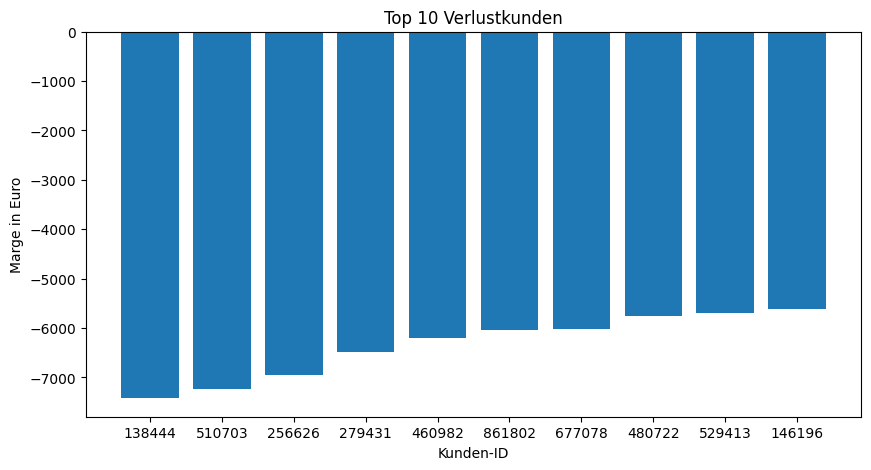

In [18]:
top_verluste = df_risiko_all.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_verluste["Kunden_ID"].astype(str),
    top_verluste["Marge_Euro"]
)

plt.title("Top 10 Verlustkunden")
plt.xlabel("Kunden-ID")
plt.ylabel("Marge in Euro")

plt.show()

In [19]:
print("Anzahl Verlustkunden:")
print(len(df_risiko_all))

print("\nGesamter Portfolioverlust in Euro:")
print(df_risiko_all["Marge_Euro"].sum().round(2))

Anzahl Verlustkunden:
305

Gesamter Portfolioverlust in Euro:
-488925.82


In [20]:
branchen_verluste = (
    df_risiko_all.groupby("Branche")["Marge_Euro"]
    .sum()
    .sort_values()
)

print(branchen_verluste)

Branche
Bäckerei             -109829.88
Logistik             -105837.30
Metallverarbeitung    -95158.36
Hotel                 -93781.09
Supermarkt            -84319.19
Name: Marge_Euro, dtype: float64


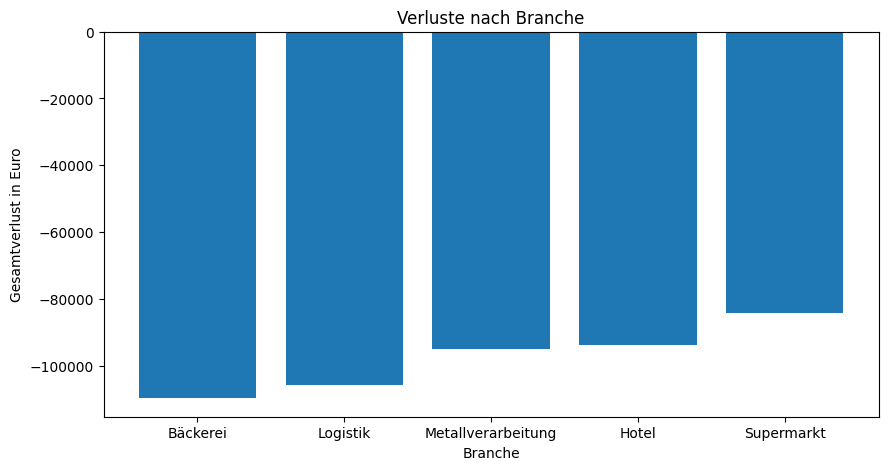

In [21]:
plt.figure(figsize=(10,5))

plt.bar(
    branchen_verluste.index,
    branchen_verluste.values
)

plt.title("Verluste nach Branche")
plt.xlabel("Branche")
plt.ylabel("Gesamtverlust in Euro")

plt.show()

In [22]:
monats_verluste = (
    df_risiko_all.groupby("Monat")["Marge_Euro"]
    .sum()
    .sort_values()
)

print(monats_verluste)

Monat
Februar   -198353.34
Januar    -156551.39
März      -134021.09
Name: Marge_Euro, dtype: float64


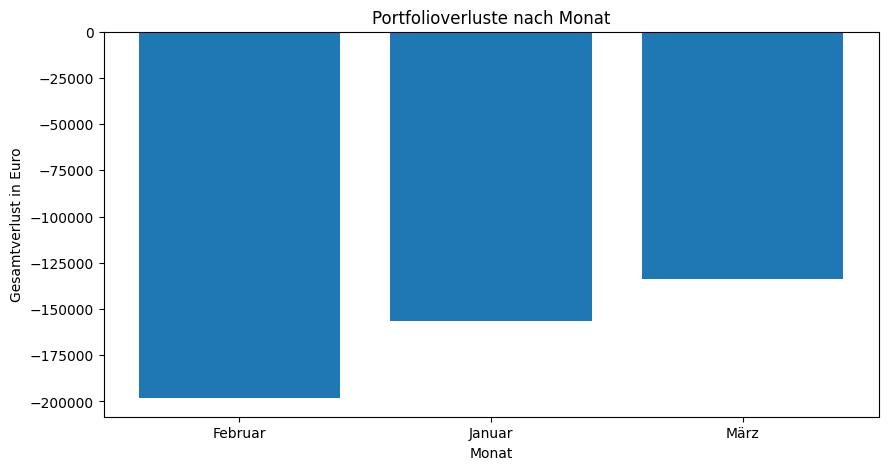

In [23]:
plt.figure(figsize=(10,5))

plt.bar(
    monats_verluste.index,
    monats_verluste.values
)

plt.title("Portfolioverluste nach Monat")
plt.xlabel("Monat")
plt.ylabel("Gesamtverlust in Euro")

plt.show()